<div style="background-color: steelblue; padding: 10px; border-radius: 5px;">
    <p style="margin: 10;"></p>
    <h1 style="text-align: center; margin: 0; font-weight: bold; color: white;">SWOT OMIP : Seasonality ratio</h1>
    <p style="margin: 10;"></p>
</div>


## 📦**Imports** 

In [24]:
%%time

##################################
#Imports

from datetime import datetime
import s3fs
import xarray as xr
import pyinterp
from widetrax import DataPreprocessing as dp
from widetrax import Spectra as sp
import numpy as np
import json
from watermark import watermark
import time
import platform
from shapely.geometry import shape, box

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
#from widetrax import Spectra as sp
import plot_psd1Xglobal1 as pp2X
import cum_sp as cs

CPU times: user 100 μs, sys: 2 μs, total: 102 μs
Wall time: 108 μs


## **Load boxes position**

In [25]:
def plot_fig(ax,imodel,lon_edges,lat_edges,ZW,ZS,valmin,valmax,model,posx,posy):
    ax[posx,posy].add_feature(cfeature.COASTLINE)
    ax[posx,posy].add_feature(cfeature.LAND, facecolor="lightgray")
    mesh = ax[posx,posy].pcolormesh(
        lon_edges,
        lat_edges,
        np.squeeze(ZW[imodel,:,:]/ZS[imodel,:,:]),
        vmin=valmin,
        vmax=valmax,
        cmap='seismic',
        transform=ccrs.PlateCarree()
    )
    ax[posx,posy].set_title(model[imodel])
    ax[posx,posy] = ax[posx,posy].gridlines(draw_labels=True,linewidth=0.2)
    ax[posx,posy].bottom_labels = True
    ax[posx,posy].top_labels = False
    ax[posx,posy].right_labels = False
    ax[posx,posy].left_labels = True
    ax[posx,posy].xlines = False
    ax[posx,posy].ylines = False
    return ax, mesh

In [26]:
# CONFIG

# NOT MODIFY

roi = {
        "lon_min": -180,
        "lon_max": 180,
        "lat_min": -90,
        "lat_max": 90
}
pos_reg=[-180, -90, 180, 90]

with open("mostly_ocean_boxes_filtered.geojson") as f:
    data = json.load(f)

roi_poly = box(roi["lon_min"], roi["lat_min"],
               roi["lon_max"], roi["lat_max"])

selected = []

for feature in data["features"]:
    poly = shape(feature["geometry"])
    if poly.intersects(roi_poly):
        selected.append(poly)

north_boxes = []
south_boxes = []

for i, feature in enumerate(data["features"]):

    coords = feature["geometry"]["coordinates"][0]
    lats = [c[1] for c in coords]
    lat_center = sum(lats) / len(lats)
    if lat_center >= 0:
        north_boxes.append(i)
    else:
        south_boxes.append(i)

print("North boxes:", len(north_boxes))
print("South boxes:", len(south_boxes))
print(north_boxes)

North boxes: 93
South boxes: 189
[189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221, 222, 223, 224, 225, 226, 227, 228, 229, 230, 231, 232, 233, 234, 235, 236, 237, 238, 239, 240, 241, 242, 243, 244, 245, 246, 247, 248, 249, 250, 251, 252, 253, 254, 255, 256, 257, 258, 259, 260, 261, 262, 263, 264, 265, 266, 267, 268, 269, 270, 271, 272, 273, 274, 275, 276, 277, 278, 279, 280, 281]


In [5]:
1/freqJASM[poswl[0]]

array([137.11111111, 123.4       , 112.18181818, 102.83333333,
        94.92307692,  88.14285714,  82.26666667,  77.125     ,
        72.58823529,  68.55555556,  64.94736842,  61.7       ,
        58.76190476,  56.09090909,  53.65217391,  51.41666667])

## **Plotting**
**Estimate the Winter/Summer ratio.**
* In the Southern Hemisphere this corresponds to JAS/JFM, while in the Northern Hemisphere it is JFM/JAS.
  

In [27]:
import importlib

importlib.reload(cs)

models=["GLO12","GLO36","NOC12","NOC025","SWOT"]
models=["GLO12V4","GLO36V1","NOC12","NOC025","SWOT"]
psdsW, psdsS,freqJAS=cs.season_cum(models,selected,50,150,north_boxes,south_boxes)

ZW,ZS=cs.cum_sum(psdsW,psdsS)


/Users/contrema/Documents/Postdoc/SWOTv2/cum_sp.py:48: RuntimeWarning: divide by zero encountered in divide
  wavelength=1/np.array(freqJFM)


**Plotting Ratio**

/var/folders/c9/n_765b212hs2ss0sxlp635dr0000gp/T/ipykernel_3524/887591763.py:7: RuntimeWarning: invalid value encountered in divide
  np.squeeze(ZW[imodel,:,:]/ZS[imodel,:,:]),
/var/folders/c9/n_765b212hs2ss0sxlp635dr0000gp/T/ipykernel_3524/887591763.py:7: RuntimeWarning: invalid value encountered in divide
  np.squeeze(ZW[imodel,:,:]/ZS[imodel,:,:]),
/var/folders/c9/n_765b212hs2ss0sxlp635dr0000gp/T/ipykernel_3524/887591763.py:7: RuntimeWarning: invalid value encountered in divide
  np.squeeze(ZW[imodel,:,:]/ZS[imodel,:,:]),
/var/folders/c9/n_765b212hs2ss0sxlp635dr0000gp/T/ipykernel_3524/887591763.py:7: RuntimeWarning: invalid value encountered in divide
  np.squeeze(ZW[imodel,:,:]/ZS[imodel,:,:]),
/var/folders/c9/n_765b212hs2ss0sxlp635dr0000gp/T/ipykernel_3524/887591763.py:7: RuntimeWarning: invalid value encountered in divide
  np.squeeze(ZW[imodel,:,:]/ZS[imodel,:,:]),


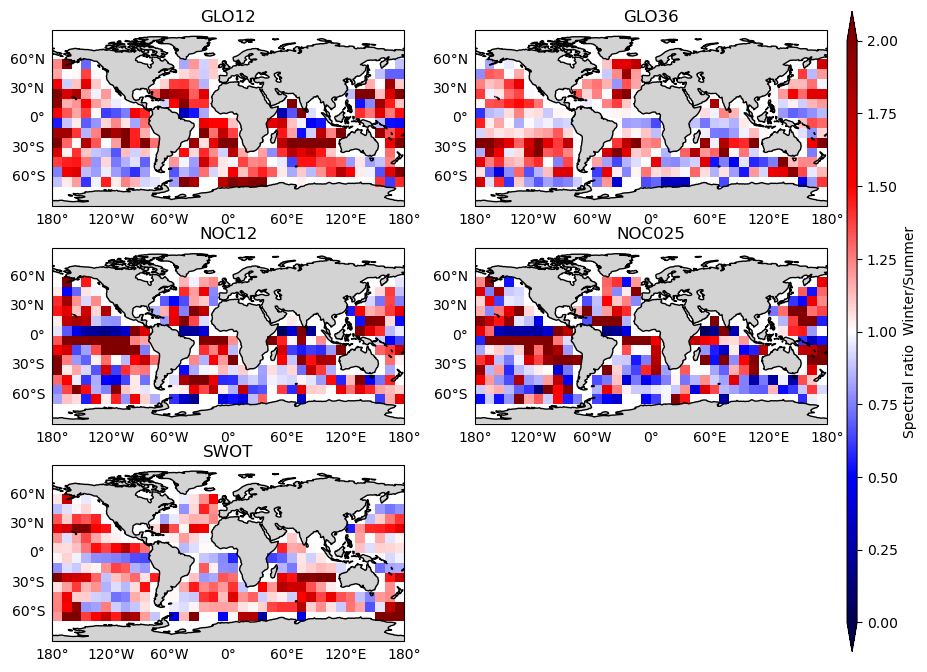

[198. 173. 166. 147. 196.]
[ 82. 107. 114. 133.  84.]
[75. 47. 74. 75. 49.]


/var/folders/c9/n_765b212hs2ss0sxlp635dr0000gp/T/ipykernel_3524/3848134018.py:37: RuntimeWarning: invalid value encountered in divide
  box_neg[imodel]=len(np.where(ZW[imodel,:,:]/ZS[imodel,:,:]<1)[0])
/var/folders/c9/n_765b212hs2ss0sxlp635dr0000gp/T/ipykernel_3524/3848134018.py:38: RuntimeWarning: invalid value encountered in divide
  box_pos[imodel]=len(np.where(ZW[imodel,:,:]/ZS[imodel,:,:]>1)[0])
/var/folders/c9/n_765b212hs2ss0sxlp635dr0000gp/T/ipykernel_3524/3848134018.py:44: RuntimeWarning: invalid value encountered in divide
  box_neg15[imodel]=len(np.where(ZW[imodel,:,:]/ZS[imodel,:,:]>1.5)[0])


In [28]:
model= ["GLO12","GLO36","NOC12","NOC025","SWOT"]
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

lon_edges = np.arange(-180, 181, 10)
lat_edges = np.arange(-90, 91, 10)

valmin=0
valmax=2
fig, ax = plt.subplots(3, 2,figsize=(10, 8),subplot_kw={'projection': ccrs.PlateCarree()})
fig.subplots_adjust(wspace=0.2, hspace=0.2)
#ax = plt.axes(projection=ccrs.PlateCarree())
imodel=0
ax, mesh=plot_fig(ax,imodel,lon_edges,lat_edges,ZW,ZS,valmin,valmax,model,0,0)
imodel=1
ax, mesh=plot_fig(ax,imodel,lon_edges,lat_edges,ZW,ZS,valmin,valmax,model,0,1)
imodel=2
ax, mesh=plot_fig(ax,imodel,lon_edges,lat_edges,ZW,ZS,valmin,valmax,model,1,0)
imodel=3
ax, mesh=plot_fig(ax,imodel,lon_edges,lat_edges,ZW,ZS,valmin,valmax,model,1,1)
imodel=4
ax, mesh=plot_fig(ax,imodel,lon_edges,lat_edges,ZW,ZS,valmin,valmax,model,2,0)
ax[2,1].axis("off") 

#plt.colorbar(mesh, ax=ax[0,0], orientation="vertical")
cbar_ax = fig.add_axes([0.92, 0.1, 0.01, .8])
cbar = fig.colorbar(mesh,cax=cbar_ax, orientation='vertical', fraction=0.02,  extend='both')
cbar.set_label("Spectral ratio  Winter/Summer")
plt.savefig("Fig/cum_season_model_weight.png",dpi=300,transparent=False)
plt.show()

box_pos=np.zeros((5))
box_neg=np.zeros((5))

for imodel in range(5):
    box_neg[imodel]=len(np.where(ZW[imodel,:,:]/ZS[imodel,:,:]<1)[0])
    box_pos[imodel]=len(np.where(ZW[imodel,:,:]/ZS[imodel,:,:]>1)[0])

box_pos15=np.zeros((5))
box_neg15=np.zeros((5))

for imodel in range(5):
    box_neg15[imodel]=len(np.where(ZW[imodel,:,:]/ZS[imodel,:,:]>1.5)[0])


print(box_pos)
print(box_neg)
print(box_neg15)